
##CIND820- Milestone 4

# Retail Sales Analytics and Customer Purchasing Behaviour Analysis




#1. Import libraries & Upload Data

In [1]:
#1. Import libraries & Upload Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online_Retail_Raw_Data.xlsx to Online_Retail_Raw_Data.xlsx


#2. Upload Raw dataset & Cleaning

In [3]:
df_raw = pd.read_excel("/content/Online_Retail_Raw_Data.xlsx")

df_clean = df_raw.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_customer = (
    df_clean
    .dropna(subset=["CustomerID"])
    .copy()
)

print("Cleaned dataset shape:", df_clean.shape)
print("Customer-level rows:", df_customer.shape)
print("Unique customers:", df_customer["CustomerID"].nunique())

Cleaned dataset shape: (524878, 9)
Customer-level rows: (392692, 9)
Unique customers: 4338


# 3. Create RFM Features

In [4]:
analysis_date = (
    df_customer["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm_kmeans = (
    df_customer
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
)

print("RFM dataset shape:", rfm_kmeans.shape)
rfm_kmeans.head()

RFM dataset shape: (4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
"12,346.00",326,1,"77,183.60"
"12,347.00",2,7,"4,310.00"
"12,348.00",75,4,"1,797.24"
"12,349.00",19,1,"1,757.55"
"12,350.00",310,1,334.40


# 4. RFM Distribution and Skewness

In [5]:
skewness = (
    rfm_kmeans[
        ["Recency", "Frequency", "Monetary"]
    ]
    .skew()
    .round(2)
)

skewness

,0
Recency,1.25
Frequency,12.07
Monetary,19.34


The RFM variables are expected to be positively skewed, particularly Frequency and Monetary. Because K-means uses distance-based calculations, highly skewed variables and extreme values can disproportionately influence cluster formation. Log transformation and standardization are therefore applied before clustering.

# 5. Log Transformation of RFM Variables

The Frequency and Monetary variables exhibit substantial positive skewness, while Recency is moderately skewed. To reduce the influence of extreme values and improve clustering performance, a logarithmic transformation is applied before feature scaling.

In [6]:
# Log transformation

rfm_log = rfm_kmeans.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
"12,346.00",5.79,0.69,11.25
"12,347.00",1.10,2.08,8.37
"12,348.00",4.33,1.61,7.49
"12,349.00",3.00,0.69,7.47
"12,350.00",5.74,0.69,5.82


In [7]:
log_skewness = (
    rfm_log[
        ["Recency", "Frequency", "Monetary"]
    ]
    .skew()
    .round(2)
)

log_skewness

,0
Recency,-0.38
Frequency,1.21
Monetary,0.40


### Interpretation

The logarithmic transformation substantially reduces the skewness of the Frequency and Monetary variables while moderately improving the distribution of Recency. This transformation minimizes the influence of extreme observations and produces a more balanced feature space for distance-based clustering.

# 6. Feature Scaling

Since K-means clustering is based on Euclidean distance, all variables must be placed on a common scale. Standardization ensures that Recency, Frequency, and Monetary contribute equally during cluster formation.

In [8]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=[
        "Recency",
        "Frequency",
        "Monetary"
    ],
    index=rfm_log.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
"12,346.00",1.46,-0.96,3.71
"12,347.00",-2.04,1.07,1.41
"12,348.00",0.37,0.39,0.72
"12,349.00",-0.62,-0.96,0.70
"12,350.00",1.42,-0.96,-0.61


In [9]:
#Verify scaling
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


### Interpretation

After standardization, the transformed RFM variables have approximately zero mean and unit variance. This ensures that no single variable dominates the Euclidean distance calculations used by the K-means algorithm, resulting in a more balanced clustering process.

# 7. Determine the optimal number of clusters(Elbow Method)

The elbow method is used to identify an appropriate number of clusters for K-means. The within-cluster sum of squares (inertia) was calculated for multiple values of k, and the point where the reduction in inertia begins to level off was selected as the optimal number of clusters.

In [10]:
# Elbow Method
inertia = []
k_values = range(2, 11)
for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

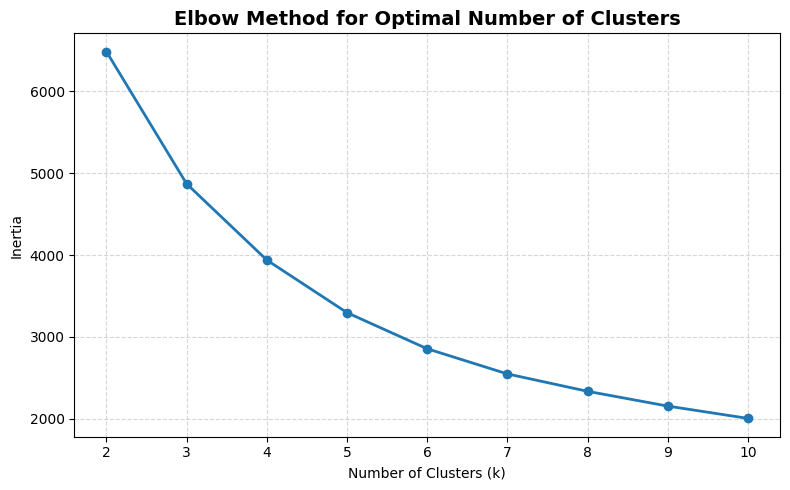

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(k_values)

plt.tight_layout()

plt.show()

### Interpretation

The elbow plot indicates that the reduction in inertia begins to level off after **k = 5**, suggesting that five clusters provide a suitable balance between cluster compactness and model simplicity. Therefore, **k = 5** was selected as the initial candidate for further evaluation using the Silhouette Score and Davies–Bouldin Index.

# 8. Cluster Validation(Silhouette Score and Davies–Bouldin Index).

To determine the most appropriate number of clusters, the K-means models were evaluated using the Silhouette Score and Davies–Bouldin Index. The Silhouette Score measures cluster separation and cohesion, where higher values indicate better-defined clusters. The Davies–Bouldin Index measures cluster similarity, where lower values indicate better clustering performance.

In [12]:
# Cluster validation

results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    silhouette = silhouette_score(rfm_scaled, labels)

    db_index = davies_bouldin_score(rfm_scaled, labels)

    results.append([
        k,
        kmeans.inertia_,
        silhouette,
        db_index
    ])

validation = pd.DataFrame(
    results,
    columns=[
        "Clusters",
        "Inertia",
        "Silhouette Score",
        "Davies-Bouldin Index"
    ]
)

validation.round(3)

,Clusters,Inertia,Silhouette Score,Davies-Bouldin Index
0,2,"6,483.59",0.43,0.89
1,3,"4,869.49",0.34,1.05
2,4,"3,939.05",0.34,1.01
3,5,"3,296.71",0.32,0.99
4,6,"2,855.76",0.31,1.02
5,7,"2,548.82",0.31,0.98
6,8,"2,336.34",0.30,0.99
7,9,"2,156.01",0.28,1.02
8,10,"2,005.75",0.28,1.03


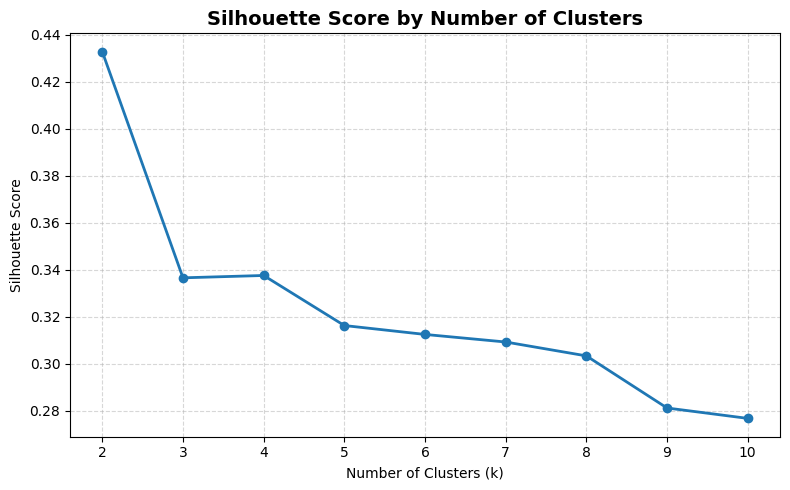

In [13]:
#Validation Charts (Silhouette Score)
plt.figure(figsize=(8,5))

plt.plot(
    validation["Clusters"],
    validation["Silhouette Score"],
    marker="o",
    linewidth=2
)

plt.title(
    "Silhouette Score by Number of Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(validation["Clusters"])

plt.tight_layout()

plt.show()

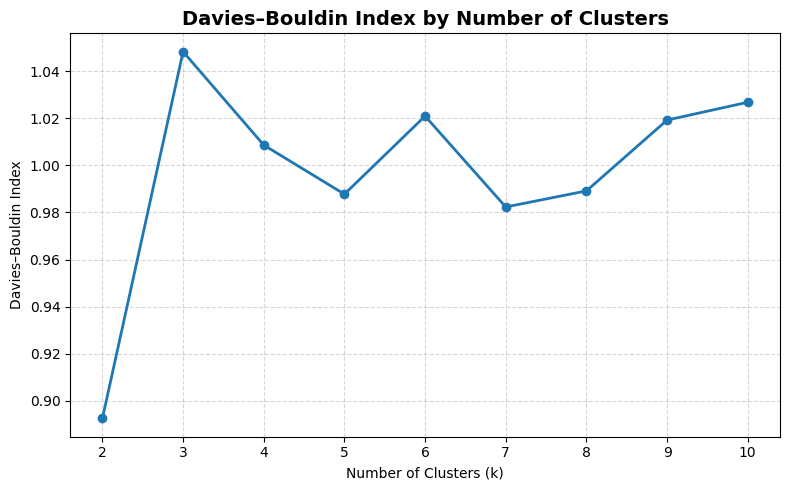

In [14]:
# Validation chart (Davies–Bouldin Index)
plt.figure(figsize=(8,5))

plt.plot(
    validation["Clusters"],
    validation["Davies-Bouldin Index"],
    marker="o",
    linewidth=2
)

plt.title(
    "Davies–Bouldin Index by Number of Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies–Bouldin Index")

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(validation["Clusters"])

plt.tight_layout()

plt.show()

### Interpretation

The validation results indicate that **k = 2** achieves the highest Silhouette Score and the lowest Davies–Bouldin Index, suggesting the strongest statistical separation between clusters. However, a two-cluster solution provides only a coarse division of customers and offers limited business insight. The elbow method indicates diminishing improvements in inertia after **k = 5**, and selecting five clusters enables a direct comparison with the five rule-based RFM customer segments. Therefore, **k = 5** was selected as the final K-means solution because it provides a practical balance between clustering performance and business interpretability.

# 9. Final K-Means Clustering

In [15]:
# Final K-Means model
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm_kmeans["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

rfm_kmeans.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
"12,346.00",326,1,"77,183.60",3
"12,347.00",2,7,"4,310.00",1
"12,348.00",75,4,"1,797.24",3
"12,349.00",19,1,"1,757.55",0
"12,350.00",310,1,334.40,2


In [16]:
#cluster profile
cluster_profile = (
    rfm_kmeans
    .groupby("Cluster")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,834,26.99,1.64,389.58
1,938,18.51,5.84,"2,179.40"
2,1209,208.35,1.21,277.22
3,1018,103.66,3.13,"1,452.36"
4,339,12.16,20.75,"13,877.16"


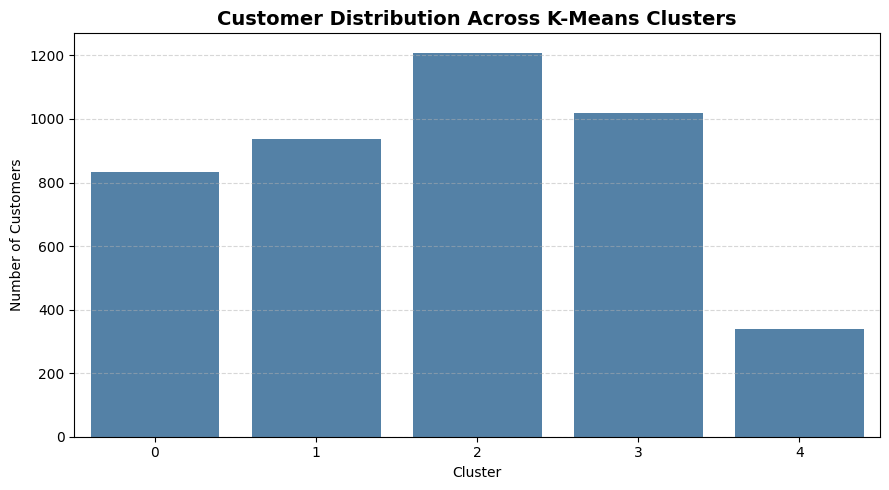

In [17]:

#Visualization
plt.figure(figsize=(9,5))

sns.barplot(
    data=cluster_profile.reset_index(),
    x="Cluster",
    y="Customers",
    color="steelblue"
)

plt.title(
    "Customer Distribution Across K-Means Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [18]:
#Cluster profile table
cluster_profile = (
    rfm_kmeans
    .groupby("Cluster")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,834,26.99,1.64,389.58
1,938,18.51,5.84,"2,179.40"
2,1209,208.35,1.21,277.22
3,1018,103.66,3.13,"1,452.36"
4,339,12.16,20.75,"13,877.16"


### Interpretation

The K-means algorithm identified five distinct customer clusters with different purchasing behaviours.

- **Cluster 4** represents the highest-value customers, with the lowest average recency (12.16 days), the highest purchase frequency (20.75), and the highest average monetary value ($13,877.16). These customers are highly active and generate the greatest business value.

- **Cluster 1** contains loyal customers who purchase regularly and contribute strong revenue, although at lower levels than Cluster 4.

- **Cluster 3** represents moderate-value customers with average purchasing frequency and spending. These customers have growth potential through targeted marketing campaigns.

- **Cluster 0** includes relatively recent but low-frequency, low-spending customers. These customers may benefit from engagement strategies to encourage repeat purchases.

- **Cluster 2** consists of inactive, low-value customers with the highest average recency (208.35 days), the lowest purchase frequency (1.21), and the lowest average monetary value ($277.22). These customers are the least engaged and represent the primary retention challenge.

# 11. Comparison of Customer Segmentation Methods
The three customer segmentation approaches were compared to evaluate their strengths, limitations, interpretability, and suitability for business decision-making. The descriptive revenue baseline provides a simple benchmark, while rule-based RFM segmentation and K-means clustering incorporate customer purchasing behaviour to generate more informative customer groups.


* #  Comparison Table

In [21]:
comparison_table = pd.DataFrame({
    "Evaluation Criterion": [
        "Variables Used",
        "Method",
        "Behavioural Information",
        "Customer Segments",
        "Interpretability",
        "Marketing Insights",
        "Model Evaluation",
        "Main Limitation"
    ],
    "Revenue Baseline": [
        "Monetary",
        "Revenue Ranking",
        "No",
        "Revenue Groups",
        "High",
        "Limited",
        "Not Required",
        "Ignores customer behaviour"
    ],
    "Rule-Based RFM": [
        "Recency, Frequency, Monetary",
        "Rule-Based Scoring",
        "Yes",
        "Five Business Segments",
        "High",
        "Strong",
        "Threshold Sensitivity",
        "Depends on thresholds"
    ],
    "K-Means Clustering": [
        "Recency, Frequency, Monetary",
        "Unsupervised Machine Learning",
        "Yes",
        "Five Data-Driven Clusters",
        "Moderate",
        "Strong",
        "Elbow Method, Silhouette Score, Davies–Bouldin Index",
        "Requires post-cluster interpretation"
    ]
})

comparison_table
display(comparison_table)

,Evaluation Criterion,Revenue Baseline,Rule-Based RFM,K-Means Clustering
0,Variables Used,Monetary,"Recency, Frequency, Monetary","Recency, Frequency, Monetary"
1,Method,Revenue Ranking,Rule-Based Scoring,Unsupervised Machine Learning
2,Behavioural Information,No,Yes,Yes
3,Customer Segments,Revenue Groups,Five Business Segments,Five Data-Driven Clusters
4,Interpretability,High,High,Moderate
5,Marketing Insights,Limited,Strong,Strong
6,Model Evaluation,Not Required,Threshold Sensitivity,"Elbow Method, Silhouette Score, Davies–Bouldin..."
7,Main Limitation,Ignores customer behaviour,Depends on thresholds,Requires post-cluster interpretation


### Interpretation
The comparison shows that each segmentation method provides different business insights. The descriptive revenue baseline ranks customers by spending only, while rule-based RFM incorporates purchasing behaviour using recency, frequency, and monetary value. K-means clustering automatically identifies behavioural customer groups without predefined rules. Together, these approaches provide complementary insights, demonstrating that behavioural segmentation offers more comprehensive customer understanding than revenue ranking alone.

# 12. Final Model Selection
The descriptive revenue baseline, rule-based RFM segmentation, and K-means clustering were evaluated using business interpretability, customer behaviour analysis, and clustering performance. The final model was selected based on its ability to provide actionable business insights while remaining easy to interpret and implement.

In [22]:
final_model = pd.DataFrame({

    "Criterion": [
        "Business Interpretability",
        "Behavioural Insights",
        "Ease of Implementation",
        "Validation Results",
        "Business Suitability"
    ],

    "Selected Method": [
        "High",
        "High",
        "Easy",
        "Supported by K-Means",
        "Rule-Based RFM"
    ]

})

display(final_model)

,Criterion,Selected Method
0,Business Interpretability,High
1,Behavioural Insights,High
2,Ease of Implementation,Easy
3,Validation Results,Supported by K-Means
4,Business Suitability,Rule-Based RFM


### Interpretation

The **rule-based RFM segmentation** was selected as the final customer segmentation method because it provides the best balance between business interpretability and customer behavioural analysis. Unlike the descriptive revenue baseline, RFM considers recency, frequency, and monetary value, producing meaningful customer segments that support targeted marketing and retention strategies. Although K-means clustering successfully identified similar behavioural patterns, it requires additional interpretation before the clusters can be used in practice. Therefore, rule-based RFM was selected as the preferred business solution, while K-means was used to validate the underlying customer segmentation patterns.

#13. Business Recommendations

The customer segmentation results provide several opportunities to improve customer retention, marketing effectiveness, and customer relationship management. Based on the findings from the descriptive revenue baseline, rule-based RFM segmentation, and K-means clustering, the following business recommendations are proposed.

- Continue rewarding **Champions** through exclusive promotions, loyalty programs, and personalized offers to maximize customer lifetime value.

- Increase engagement with **Loyal Customers** by encouraging repeat purchases through cross-selling and upselling campaigns.

- Develop targeted marketing campaigns for **Potential Loyalists** to strengthen customer loyalty and increase purchase frequency.

- Implement retention strategies for **At Risk** customers using reminder emails, discounts, and personalized incentives before customer inactivity increases.

- Evaluate **Lost Customers** through win-back campaigns while considering the cost-effectiveness of continued marketing investment.

- Regularly monitor customer purchasing behaviour by updating the RFM analysis to support data-driven marketing and customer relationship management.

# 14. Final Conclusion

This project evaluated three customer segmentation approaches: a descriptive revenue baseline, rule-based RFM segmentation, and K-means clustering using the Online Retail dataset. The descriptive revenue baseline demonstrated that customer revenue is highly concentrated among a small proportion of customers, while rule-based RFM segmentation produced clear and interpretable behavioural customer groups. K-means clustering further validated the presence of distinct customer purchasing patterns using an unsupervised machine learning approach.

Overall, the results show that combining descriptive analysis with behavioural segmentation provides valuable insights for customer relationship management, targeted marketing, and customer retention. Among the evaluated approaches, the rule-based RFM segmentation is recommended as the preferred business solution because it balances business interpretability, practical implementation, and meaningful customer insights, while K-means clustering serves as a complementary validation technique.